# Systematic uncertainties
## Calculate the systematic covariance matrices

### Load utility functions

In [1]:
gROOT->ProcessLine(".L ../UtilityFunctions.C");

### Number of toys

In [2]:
const std::size_t NToys = 1000;

### Function for loading fit results

In [3]:
std::vector<std::vector<double> > GetManyFitsResults(const std::string &Systematic) {
    std::string SystDir("/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins_20fb/cisiFit/");
    SystDir += Systematic + "Systematics/";
    TFile FirstFile((SystDir + "Fit0.root").c_str(), "READ");
    std::vector<std::string> *VariableNames = nullptr;
    FirstFile.GetObject("VariableNames", VariableNames);
    std::size_t NParameters = VariableNames->size();
    FirstFile.Close();
    VariableNames = nullptr;
    std::vector<std::vector<double>> FitResults(NParameters);
    for(std::size_t i = 0; i < NToys; i++) {
        // Ignore some errors because of ROOT version incompatibility
        auto errorLevel = gErrorIgnoreLevel;
        gErrorIgnoreLevel = kFatal;
        TFile File((SystDir + "Fit" + std::to_string(i) + ".root").c_str(), "READ");
        gErrorIgnoreLevel = errorLevel;
        if(File.IsZombie()) {
            continue;
        }
        TParameter<int> *Status = nullptr;
        File.GetObject("Status", Status);
        if(Status->GetVal() != 0) {
            //std::cout << "Fit did not converge, status = " << Status->GetVal() << "\n";
            continue;
        }
        TParameter<int> *CovStatus = nullptr;
        File.GetObject("CovStatus", CovStatus);
        if(CovStatus->GetVal() != 3) {
            //std::cout << "Covariance matrix not valid, covQual = " << CovStatus->GetVal() << "\n";
            continue;
        }
        std::vector<double> *FitValues = nullptr;
        File.GetObject("FitValues", FitValues);
        // Check for extreme fit results
        bool ExtremeFitResults = false;
        for(std::size_t j = 1; j < 9; j++) {
            if(TMath::Abs((*FitValues)[j]) > 1.3) {
                ExtremeFitResults = true;
            }
        }
        if(ExtremeFitResults) {
            continue;
        }
        for(std::size_t j = 0; j < NParameters; j++) {
            FitResults[j].push_back((*FitValues)[j]);
        }
    }
    return FitResults;
}

### Function for plotting distributions of many fits with smearing

In [4]:
void PlotSmearedDistributions(const std::string &Systematic) {
    const auto FitValues = GetManyFitsResults(Systematic);
    static std::size_t Counter = 0;
    for(const auto &FitResults : FitValues) {
        TCanvas *c = new TCanvas(("c" + std::to_string(Counter++)).c_str(), "", 1200, 900);
        TH1D *h = new TH1D(("h" + std::to_string(Counter)).c_str(), "", 50, 0.0, 0.0);
        for(auto Value : FitResults) {
            h->Fill(Value);
        }
        h->Draw("HIST");
        c->Draw();
    }
}

### Function for calculating the covariance matrix

In [5]:
TMatrixD GetCovMatrix(const std::string &Systematic) {
    const auto FitValues = GetManyFitsResults(Systematic);
    const std::size_t NParameters = FitValues.size();
    TMatrixT<double> CovMatrix(NParameters, NParameters);
    for(std::size_t i = 0; i < NParameters; i++) {
        for(std::size_t j = i; j < NParameters; j++) {
            CovMatrix(i, j) = Covariance(FitValues[i], FitValues[j]);
            if(i != j) {
                CovMatrix(j, i) = CovMatrix(i, j);
            }
        }
    }
    return CovMatrix;
}

### Function for printing correlation matrix

In [6]:
void PrintCorrMatrix(const TMatrixT<double> &CovMatrix, std::ostream &Stream) {
    int BlankSpaces = 8;
    std::string Blank = BlankSpaces == 0 ? "" : std::string(BlankSpaces, ' ');
    int Width = 4;
    for(std::size_t i = 0; i < CovMatrix.GetNrows(); i++) {
        Stream << Blank;
        for(std::size_t j = 0; j < CovMatrix.GetNcols(); j++) {
            Stream << std::left << std::setw(Width);
            std::stringstream ss;
            ss << "$";
            if(CovMatrix(i, j) >= 0.0) {
                ss << "\\phantom{-}";
            }
            ss << std::fixed << std::setprecision(2);
            if(CovMatrix(i, i) == 0.0 || CovMatrix(j, j) == 0.0) {
                ss << 0.0 << "$";
            } else {
                ss << CovMatrix(i, j)/TMath::Sqrt(CovMatrix(i, i)*CovMatrix(j, j)) << "$";
            }
            Stream << ss.str();
            if(j == CovMatrix.GetNcols() - 1) {
                Stream << " \\\\" << "\n";
            } else {
                Stream << " & ";
            }
        }
    }
}

### Function for printing a single line of the systematic uncertainties table

In [7]:
void PrintSystematicsLine(const TMatrixT<double> &CovMatrix,
                          const std::string &Name) {
    int BlankSpaces = 8;
    std::string Blank = BlankSpaces == 0 ? "" : std::string(BlankSpaces, ' ');
    int Width = 5;
    std::cout << Blank;
    std::cout << std::left << std::setw(Width);
    std::cout << Name << " & ";
    for(std::size_t i = 0; i < CovMatrix.GetNrows(); i++) {
        std::cout << std::left << std::setw(Width);
        std::stringstream ss;
        double Multiplier = 1000.0;
        if(i == 0 || i == 16) {
            Multiplier = 100000;
        }
        ss << "$" << std::fixed << std::setprecision(1) << TMath::Sqrt(CovMatrix(i, i))*Multiplier << "$";
        std::cout << ss.str();
        if(i == 18) {
            std::cout << " \\\\" << "\n";
        } else {
            std::cout << " & ";
        }

    }
}

### Loop through the systematics

In [8]:
std::vector<std::string> Systematics{
    "STYield",
    "KLpi0STYield",
    "KeNuSTYield",
    "ExternalStrongPhases",
    "Efficiency",
    "PeakingBackgrounds",
    "KSVeto",
    "TrackingPID"
};
std::map<std::string, std::string> LaTeXNames{
    {"STYield", "ST yield"},
    {"KLpi0STYield", "$\\klong\\piz$ ST yield"},
    {"KeNuSTYield", "$\\kaonm e^+\\nu_e$ ST yield"},
    {"ExternalStrongPhases", "External strong phases"},
    {"Efficiency", "Finite MC size"},
    {"PeakingBackgrounds", "Single and double tag fit"},
    {"KSVeto", "$\\kshort$ veto "},
    {"TrackingPID", "Tracking and PID efficiency"}
};

In [9]:
TMatrixT<double> CombinedCovMatrix(19, 19);
std::ofstream File("Systematic_uncertainties_correlation_matrices.txt");
for(const auto &Systematic : Systematics) {
    File << Systematic << "\n";
    TMatrixT<double> CovMatrix;
    if(Systematic == "KSVeto") {
        TFile File("KSVeto_Systematics_CovarianceMatrix.root", "READ");
        TMatrixT<double> *Cov = nullptr;
        File.GetObject("CovMatrix", Cov);
        CovMatrix.ResizeTo(Cov->GetNrows(), Cov->GetNcols());
        CovMatrix = *Cov;
        File.Close();
    } else if(Systematic == "TrackingPID") {
        TMatrixT<double> Cov(19, 19);
        double TrackingPIDSyst = TMath::Sqrt(0.008*0.008 + 0.010*0.010 + 0.008*0.008 + 0.002*0.002);
        Cov(0, 0) = TrackingPIDSyst*TrackingPIDSyst*0.002879*0.002879;
        Cov(16, 16) = TrackingPIDSyst*TrackingPIDSyst*0.00249*0.00249;
        Cov(0, 16) = TMath::Sqrt(Cov(0, 0)*Cov(16, 16));
        Cov(16, 0) = TMath::Sqrt(Cov(0, 0)*Cov(16, 16));
        CovMatrix.ResizeTo(Cov.GetNrows(), Cov.GetNcols());
        CovMatrix = Cov;
    } else {
        auto Cov = GetCovMatrix(Systematic);
        CovMatrix.ResizeTo(Cov.GetNrows(), Cov.GetNcols());
        CovMatrix = Cov;
    }
    /*for(std::size_t i = 0; i < CovMatrix.GetNcols(); i++) {
        std::cout << TMath::Sqrt(CovMatrix(i, i)) << "\n";
    }*/
    CombinedCovMatrix += CovMatrix;
    PrintCorrMatrix(CovMatrix, File);
    PrintSystematicsLine(CovMatrix, LaTeXNames.at(Systematic));
    File << "\n";
}

        ST yield & $0.1$ & $0.6$ & $0.3$ & $0.2$ & $0.6$ & $0.0$ & $0.1$ & $0.0$ & $0.1$ & $0.0$ & $0.0$ & $0.0$ & $0.0$ & $0.0$ & $0.0$ & $0.0$ & $6.7$ & $0.1$ & $0.0$ \\
        $\klong\piz$ ST yield & $0.1$ & $3.7$ & $3.4$ & $3.4$ & $3.9$ & $0.2$ & $0.0$ & $0.2$ & $0.4$ & $0.0$ & $0.0$ & $0.1$ & $0.0$ & $0.0$ & $0.0$ & $0.1$ & $0.2$ & $0.0$ & $0.0$ \\
        $\kaonm e^+\nu_e$ ST yield & $0.6$ & $0.5$ & $0.2$ & $0.2$ & $0.5$ & $0.0$ & $0.0$ & $0.0$ & $0.1$ & $0.0$ & $0.0$ & $0.1$ & $0.0$ & $0.0$ & $0.0$ & $0.1$ & $0.0$ & $0.3$ & $0.0$ \\
        External strong phases & $0.2$ & $3.9$ & $3.1$ & $2.4$ & $4.5$ & $39.0$ & $38.9$ & $21.5$ & $34.6$ & $0.1$ & $0.1$ & $0.1$ & $0.2$ & $0.1$ & $0.2$ & $0.2$ & $2.1$ & $0.1$ & $0.4$ \\
        Finite MC size & $0.4$ & $2.9$ & $1.5$ & $1.2$ & $3.2$ & $6.0$ & $4.5$ & $4.1$ & $6.8$ & $0.3$ & $0.6$ & $0.8$ & $0.8$ & $0.7$ & $1.4$ & $1.2$ & $0.6$ & $0.4$ & $0.4$ \\
        Single and double tag fit & $0.3$ & $2.3$ & $3.6$ & $4.7$ & $1.9$ & $1.2$ & $

In [10]:
File << "Total systematic\n";
PrintCorrMatrix(CombinedCovMatrix, File);
PrintSystematicsLine(CombinedCovMatrix, "Total systematic");

        Total systematic & $4.5$ & $6.6$ & $7.4$ & $6.7$ & $9.1$ & $39.5$ & $39.7$ & $22.1$ & $35.4$ & $3.8$ & $5.6$ & $3.2$ & $11.7$ & $6.4$ & $1.7$ & $9.9$ & $8.0$ & $0.5$ & $0.6$ \\


In [11]:
File.close();

In [17]:
TMath::Sqrt(CombinedCovMatrix(0, 0))

(double) 4.4591821e-05


### Print statistical uncertainties for comparison

In [12]:
TFile File("/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins_20fb/cisiFit/PreliminaryFitResults.root", "READ");
TMatrixT<double> CovMatrix(19, 19);
std::vector<double> *Cov = nullptr;
File.GetObject("CovMatrix", Cov);
for(int i = 0; i < 19; i++) {
    for(int j = 0; j < 19; j++) {
        CovMatrix(i, j) = (*Cov)[j + 19*i];
    }
}
File.Close();
PrintSystematicsLine(CovMatrix, "Statistical");

        Statistical & $2.8$ & $77.2$ & $37.3$ & $29.4$ & $82.5$ & $220.0$ & $157.6$ & $142.1$ & $238.3$ & $2.7$ & $5.2$ & $6.9$ & $7.1$ & $6.3$ & $11.9$ & $10.5$ & $9.1$ & $8.4$ & $13.6$ \\


### Save combined covariance matrix for $F_+$ calculation

In [13]:
TFile CombinedCovMatrixFile("CombinedCovMatrix.root", "RECREATE");
CombinedCovMatrixFile.WriteObject(&CombinedCovMatrix, "CovMatrix");
CombinedCovMatrixFile.Close();

### Plot some distributions for cross checks

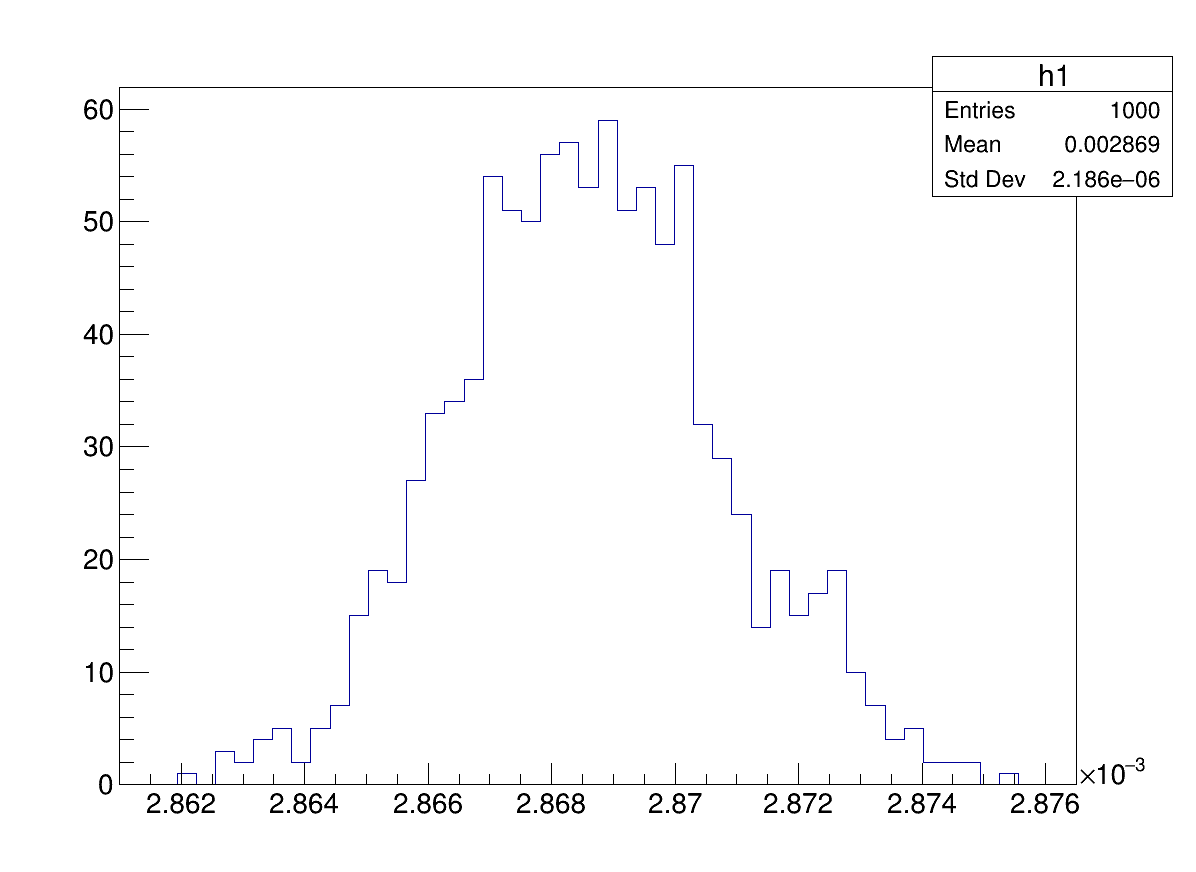

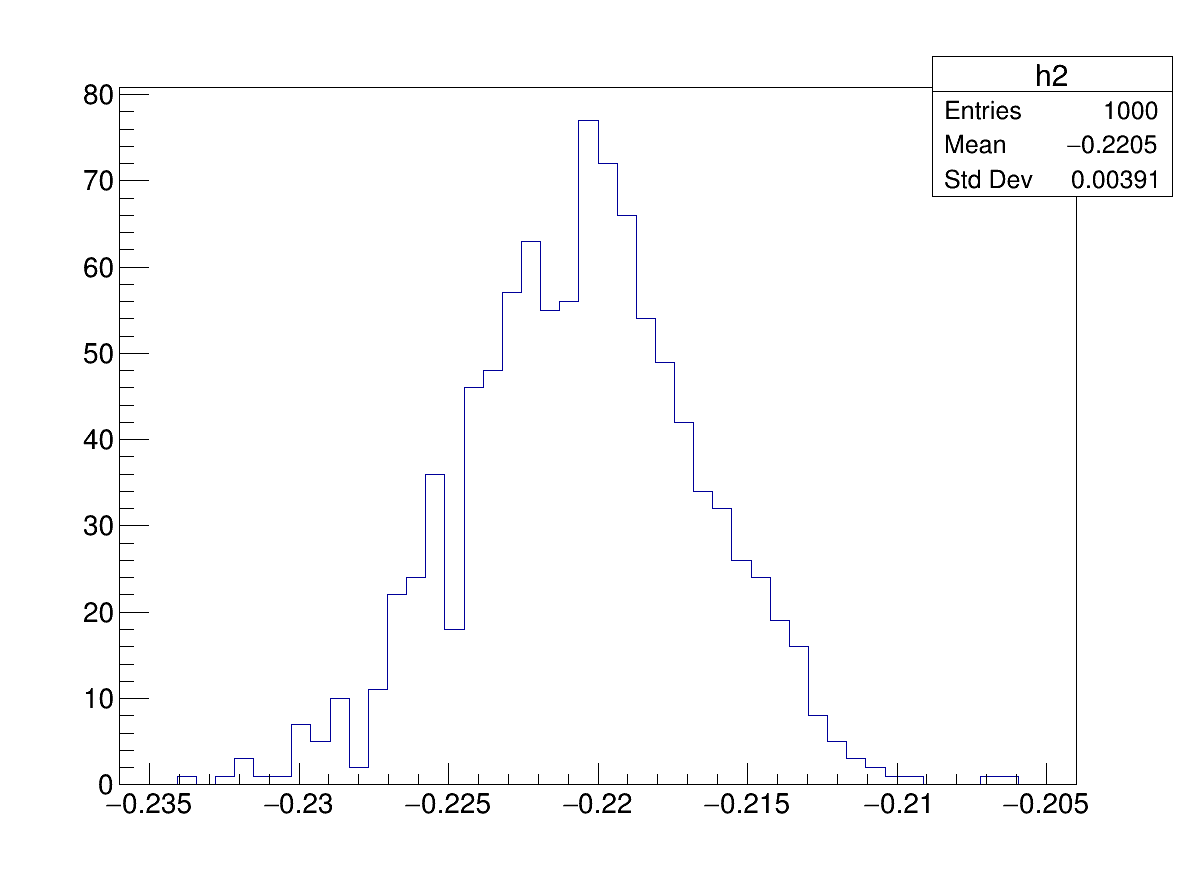

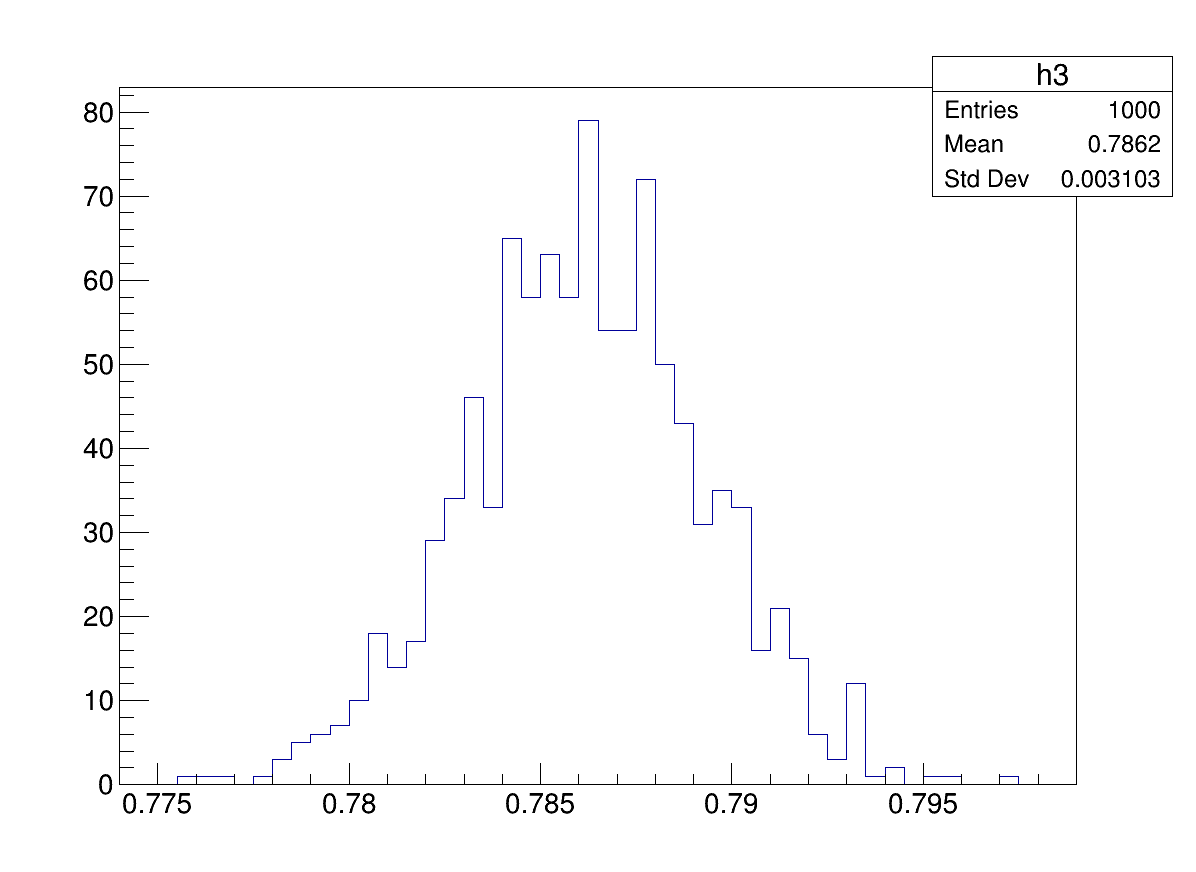

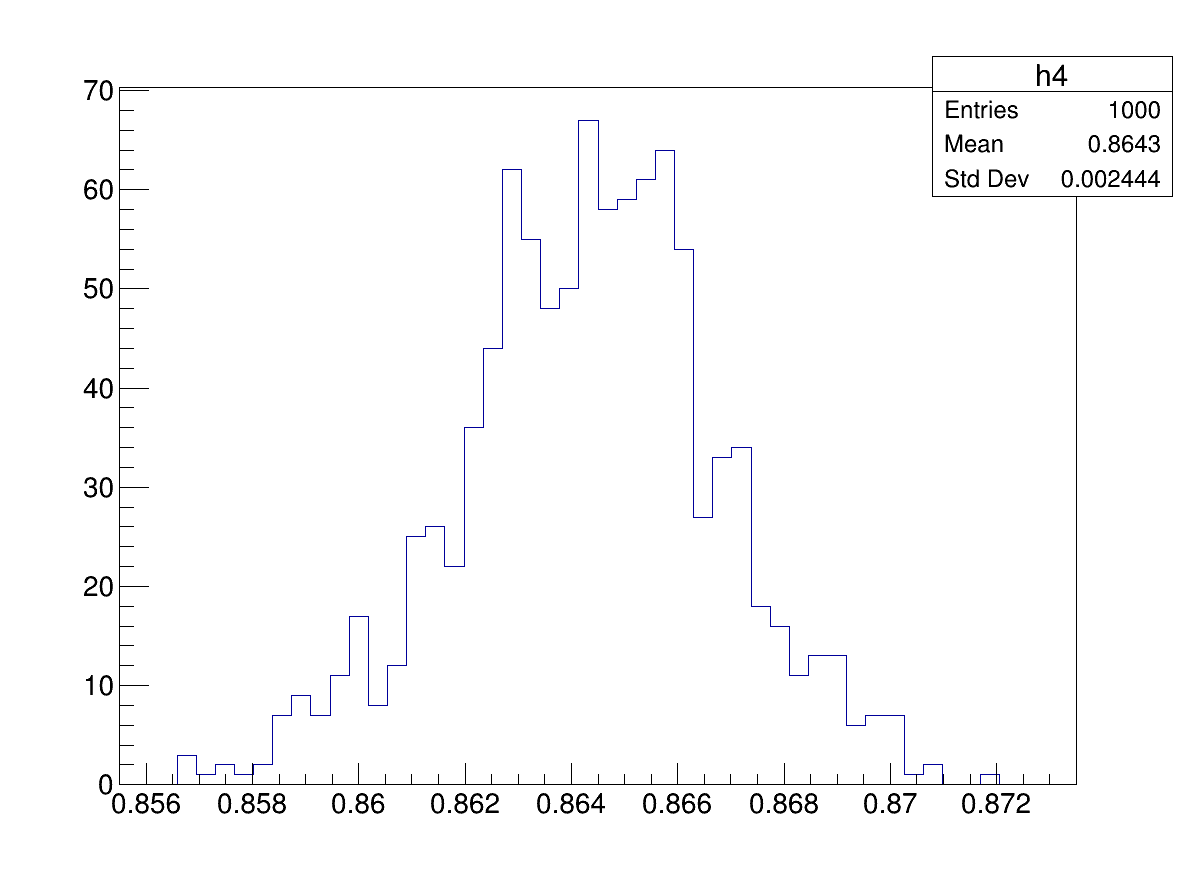

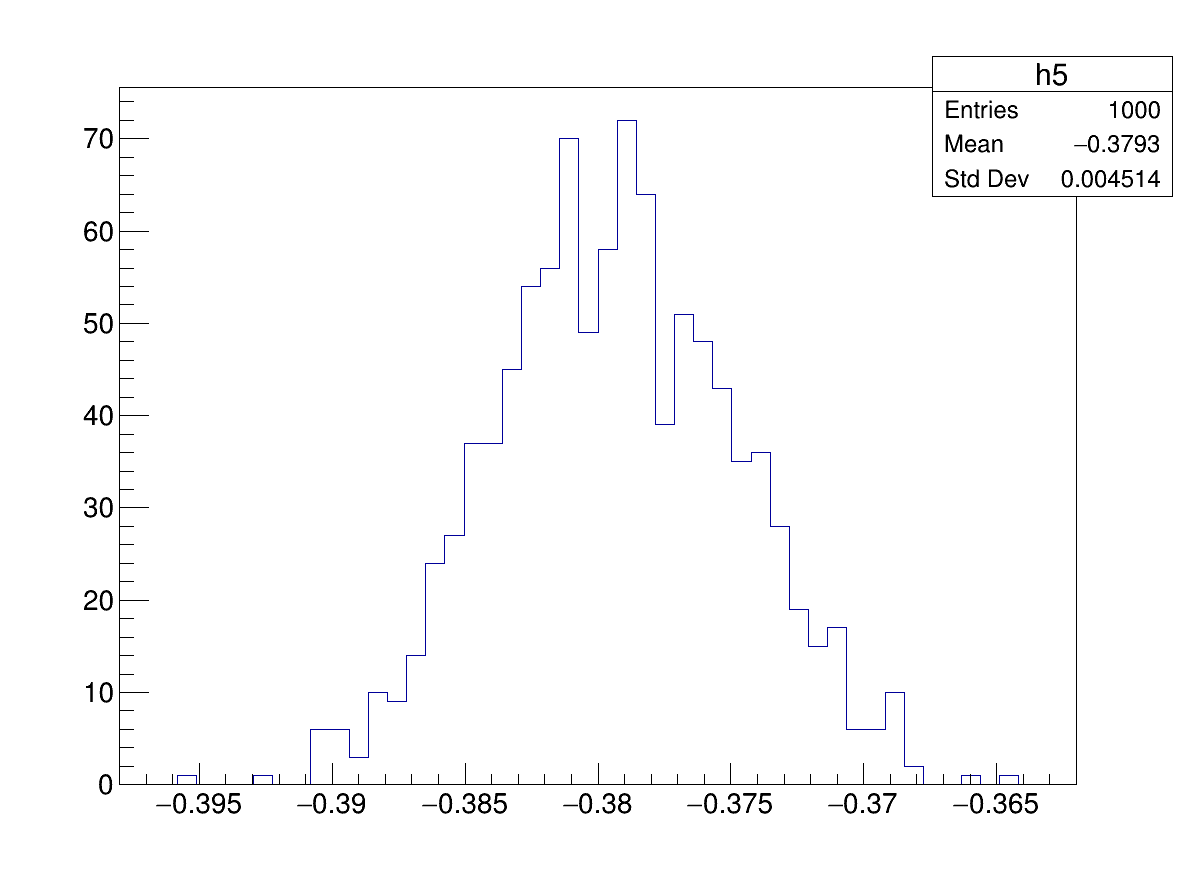

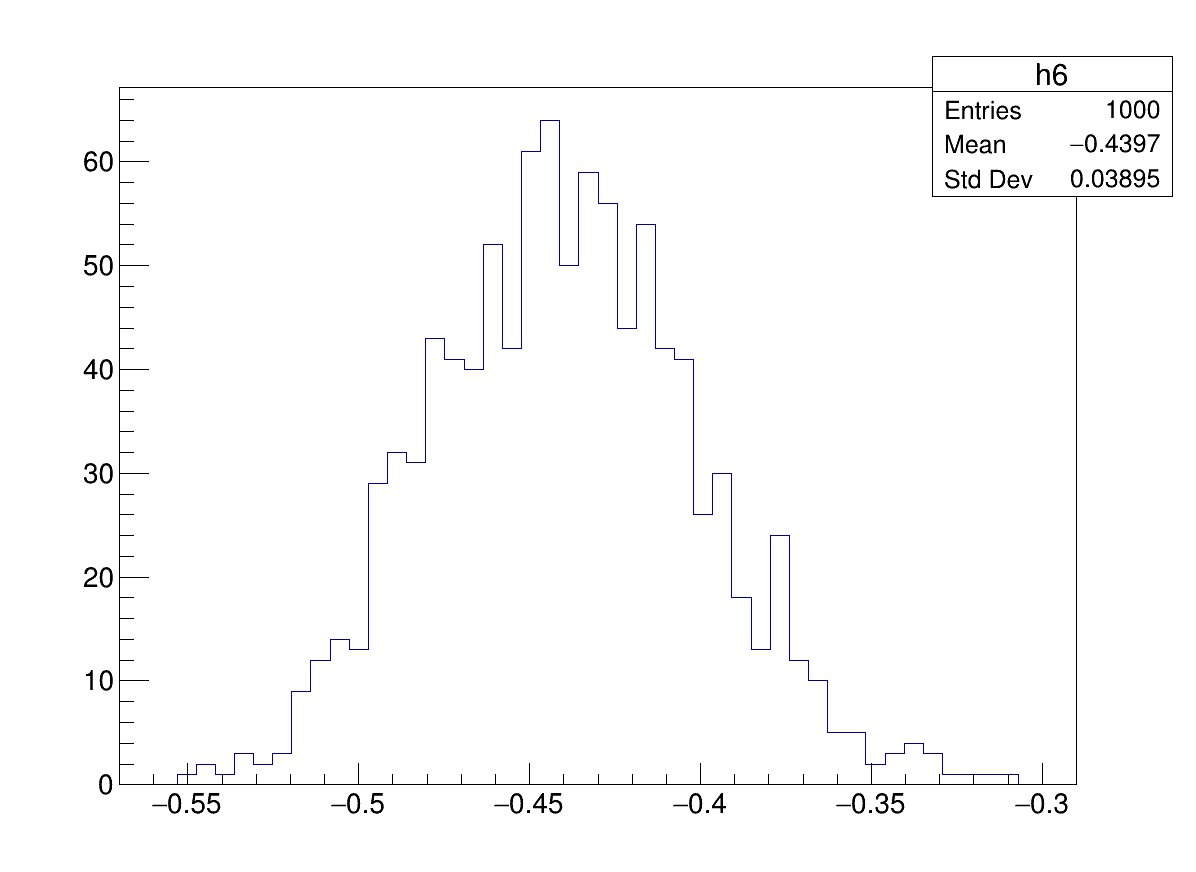

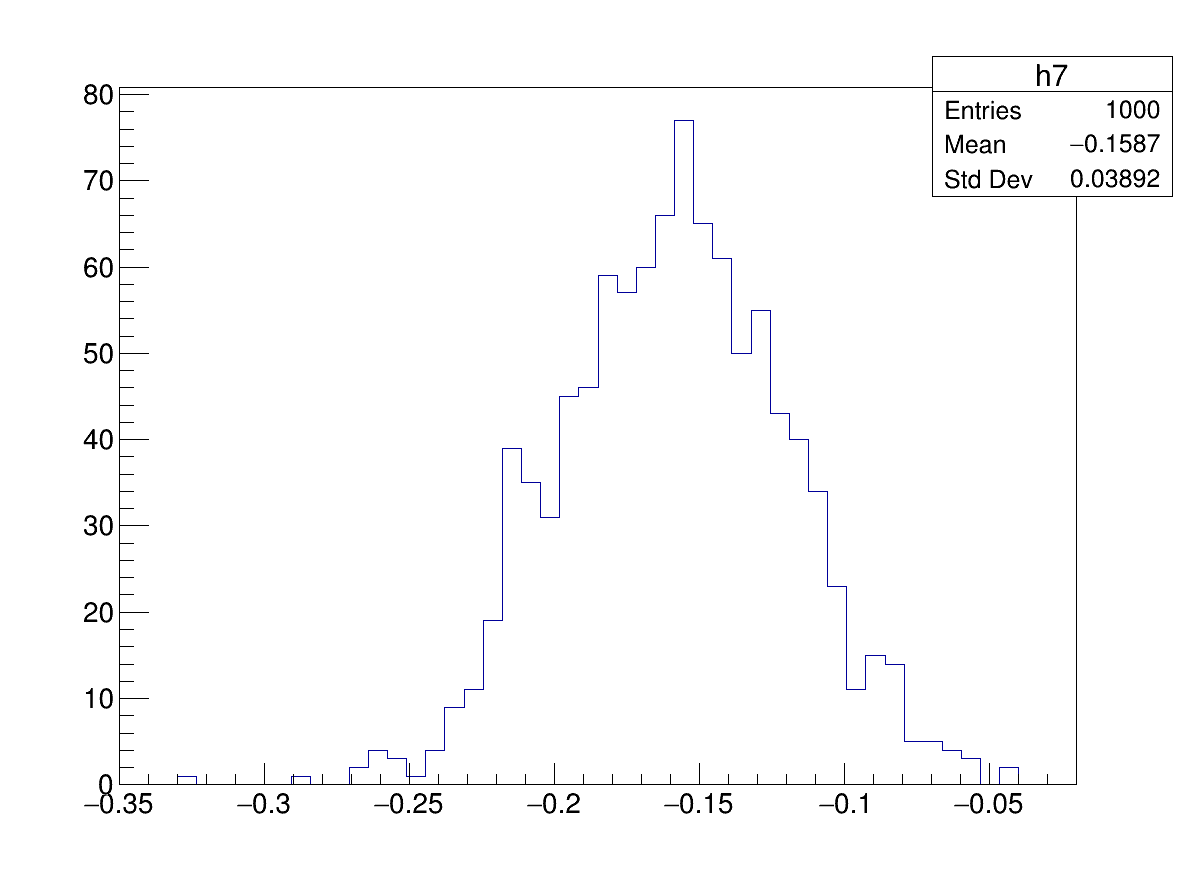

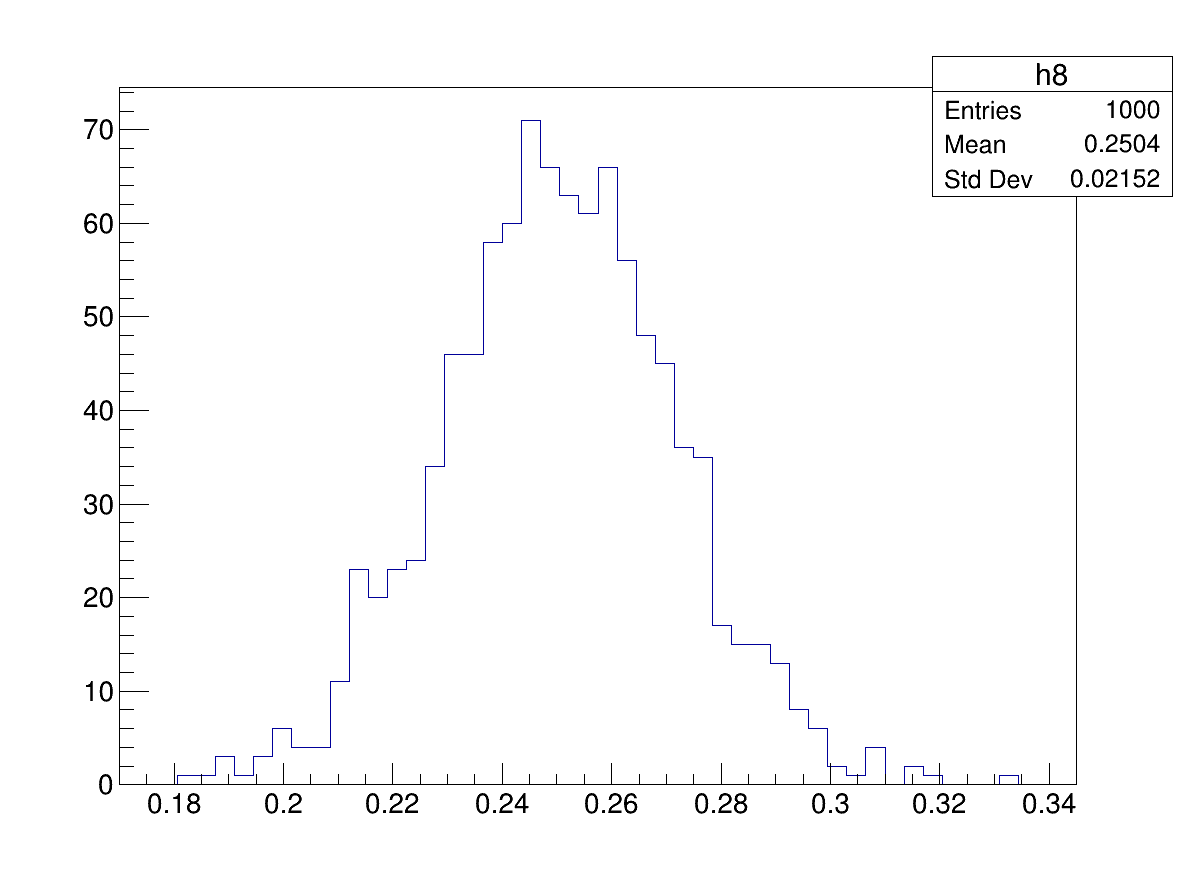

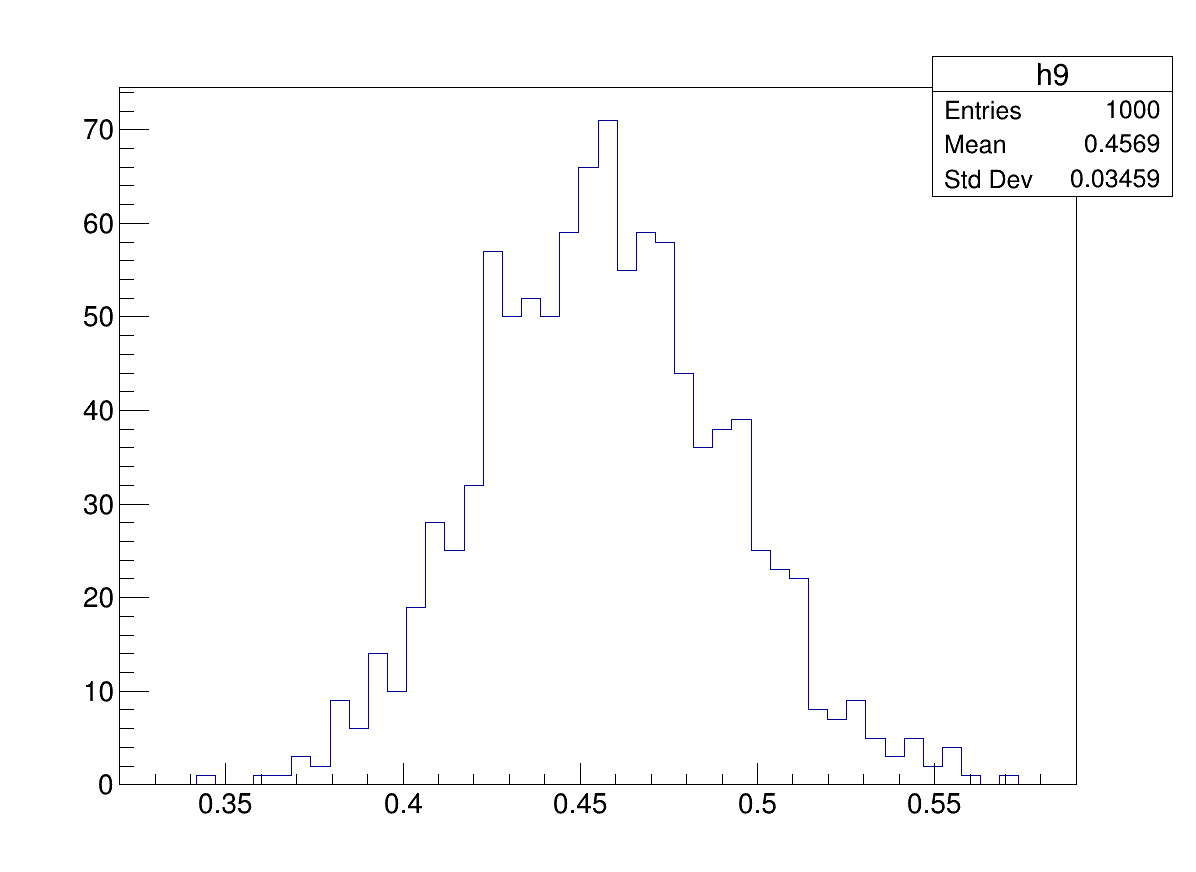

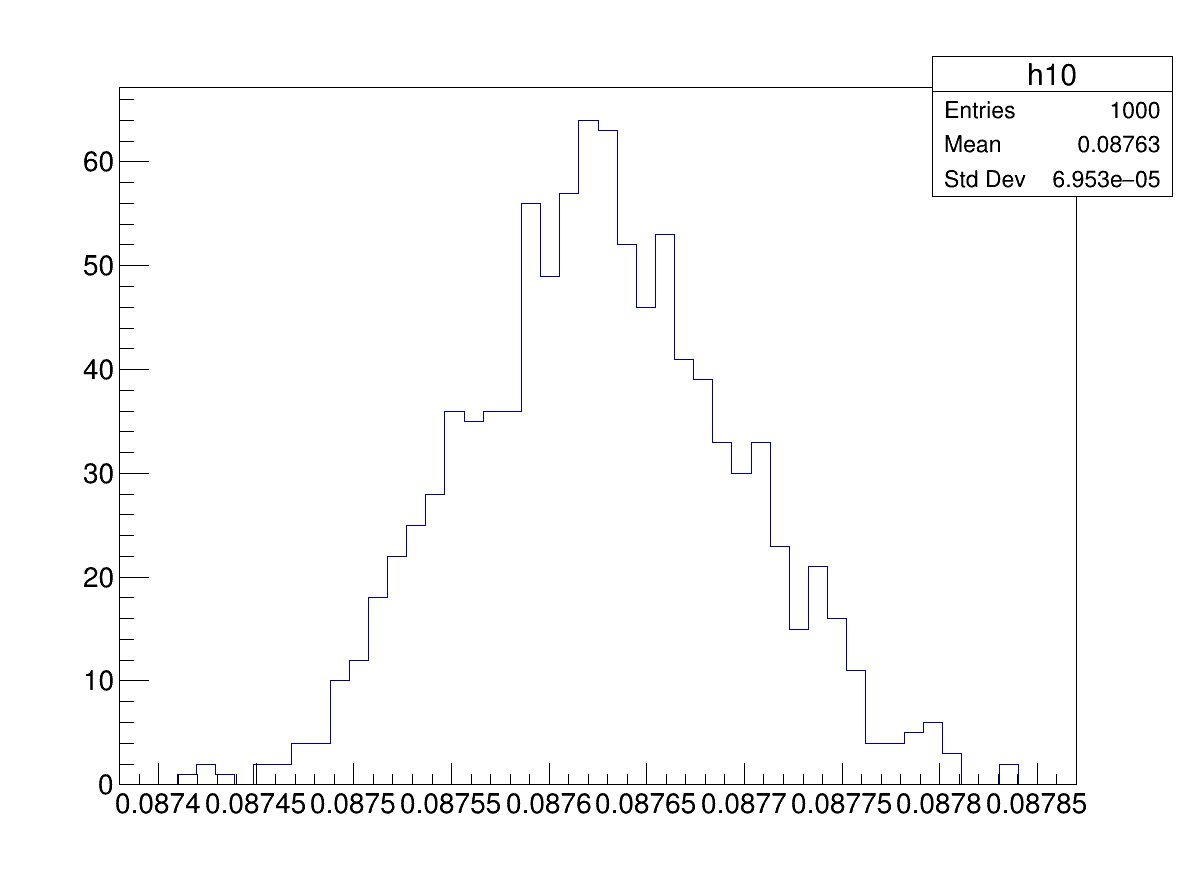

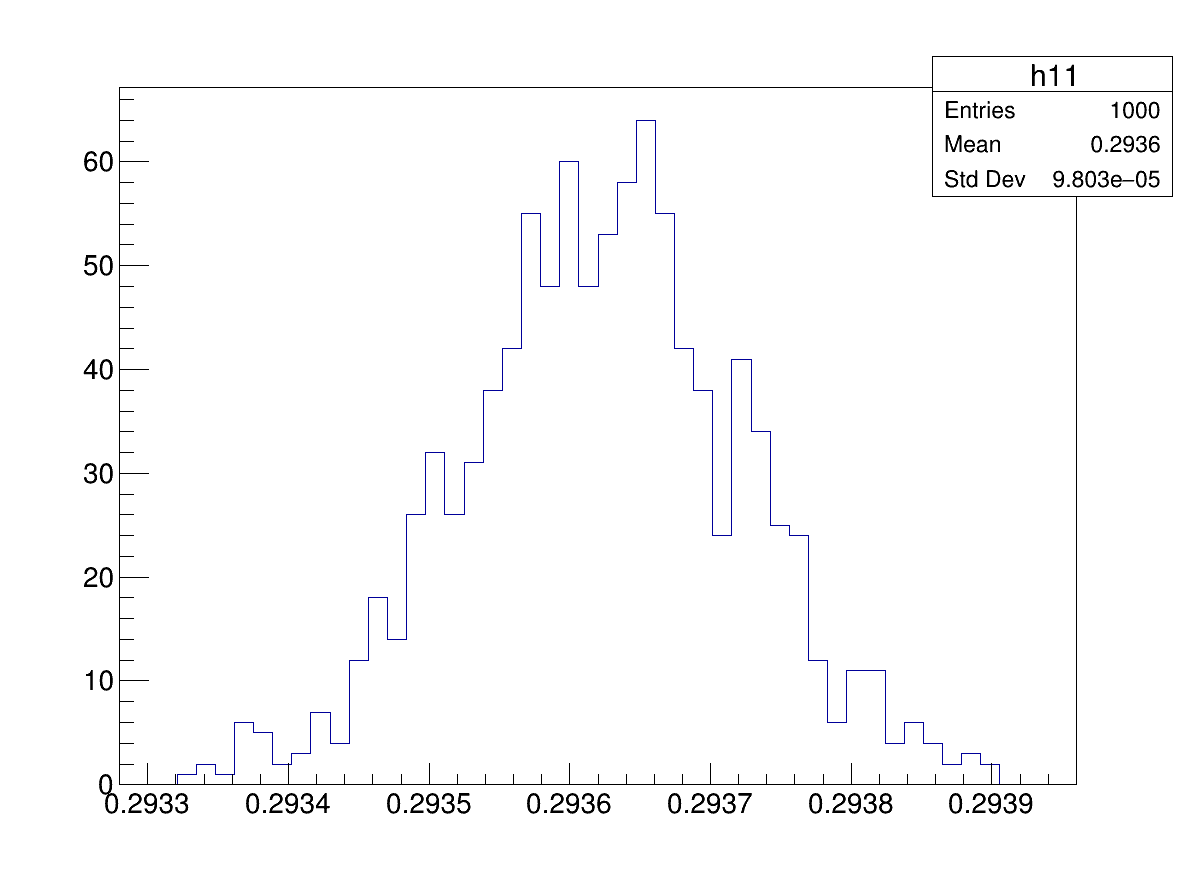

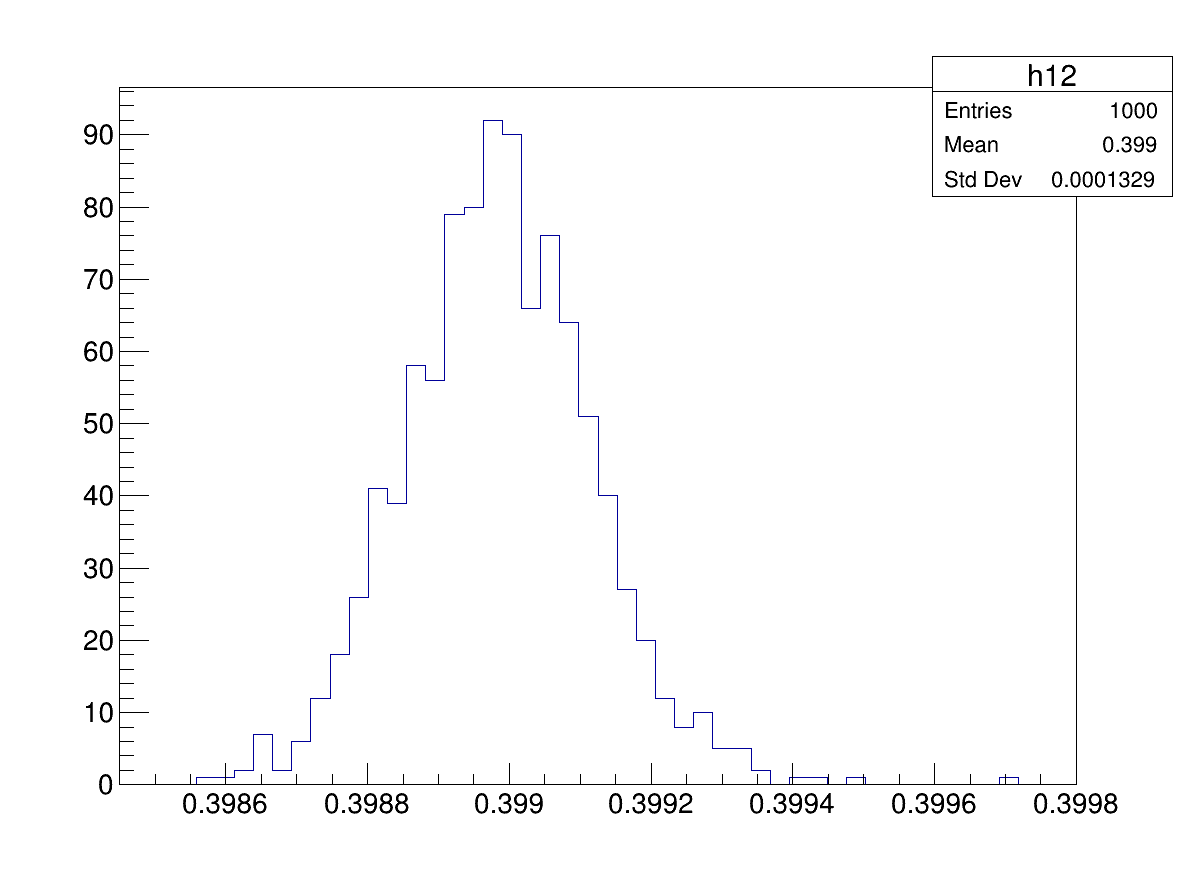

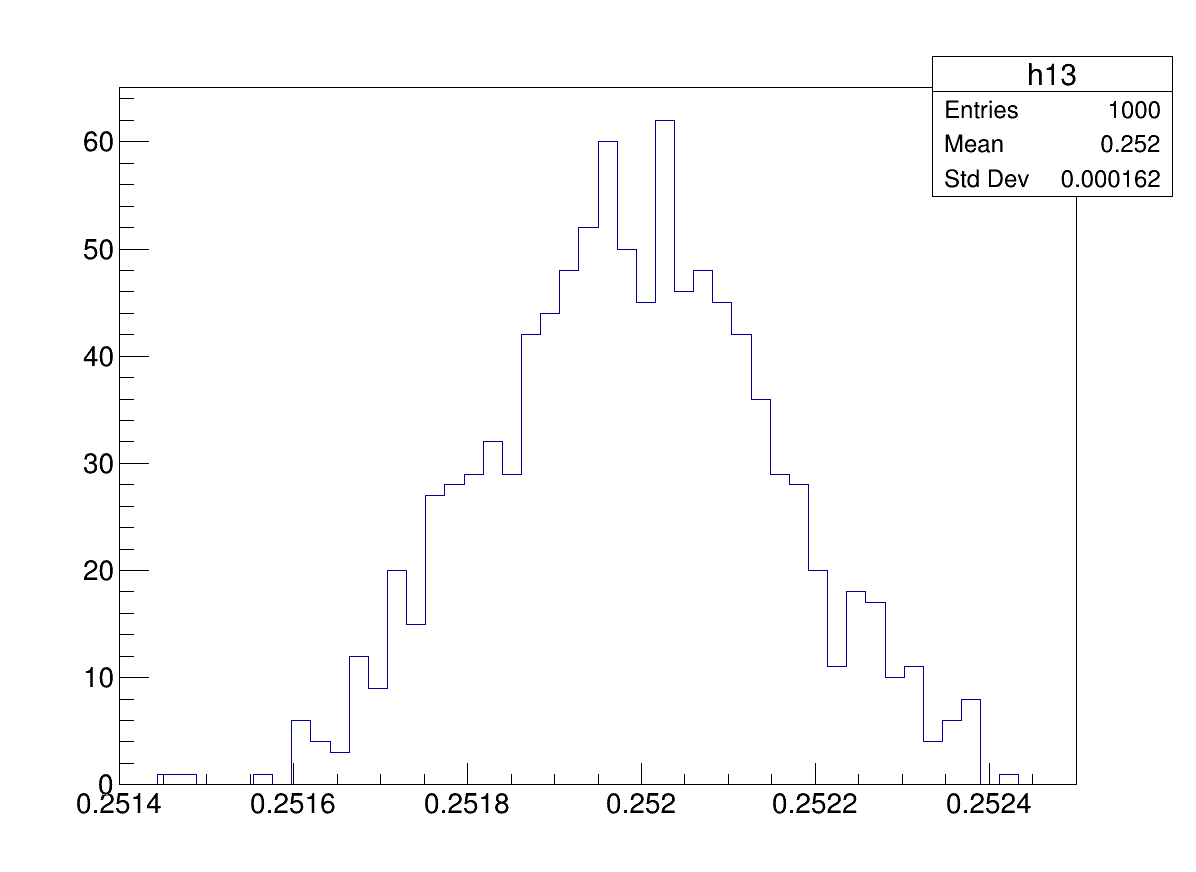

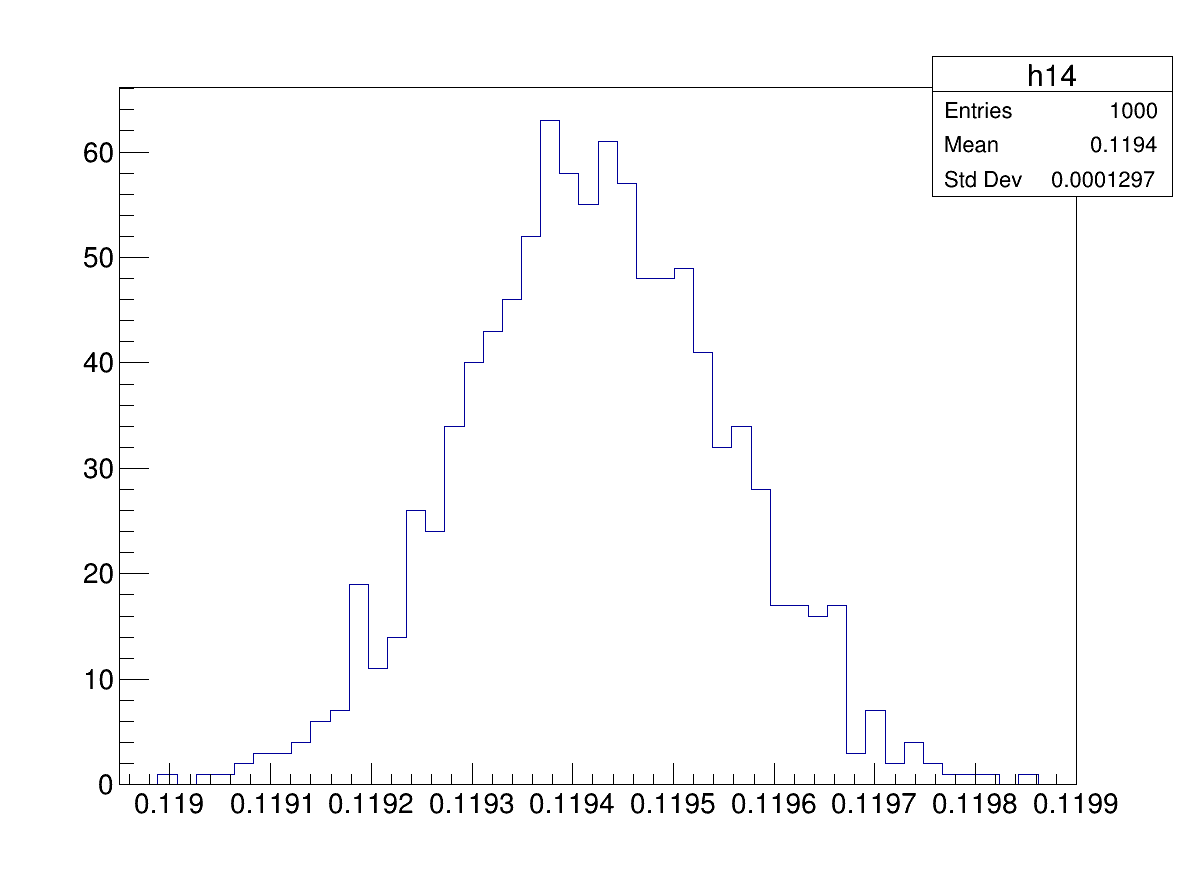

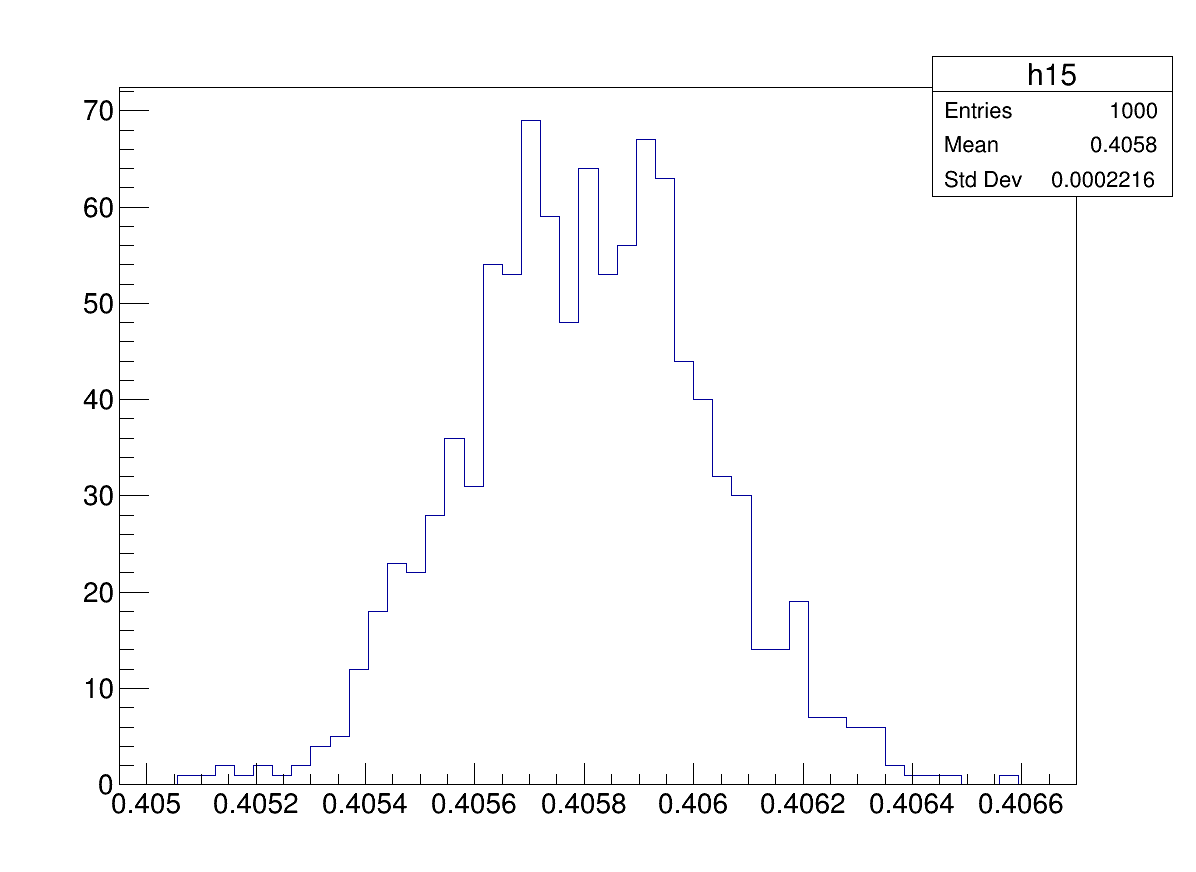

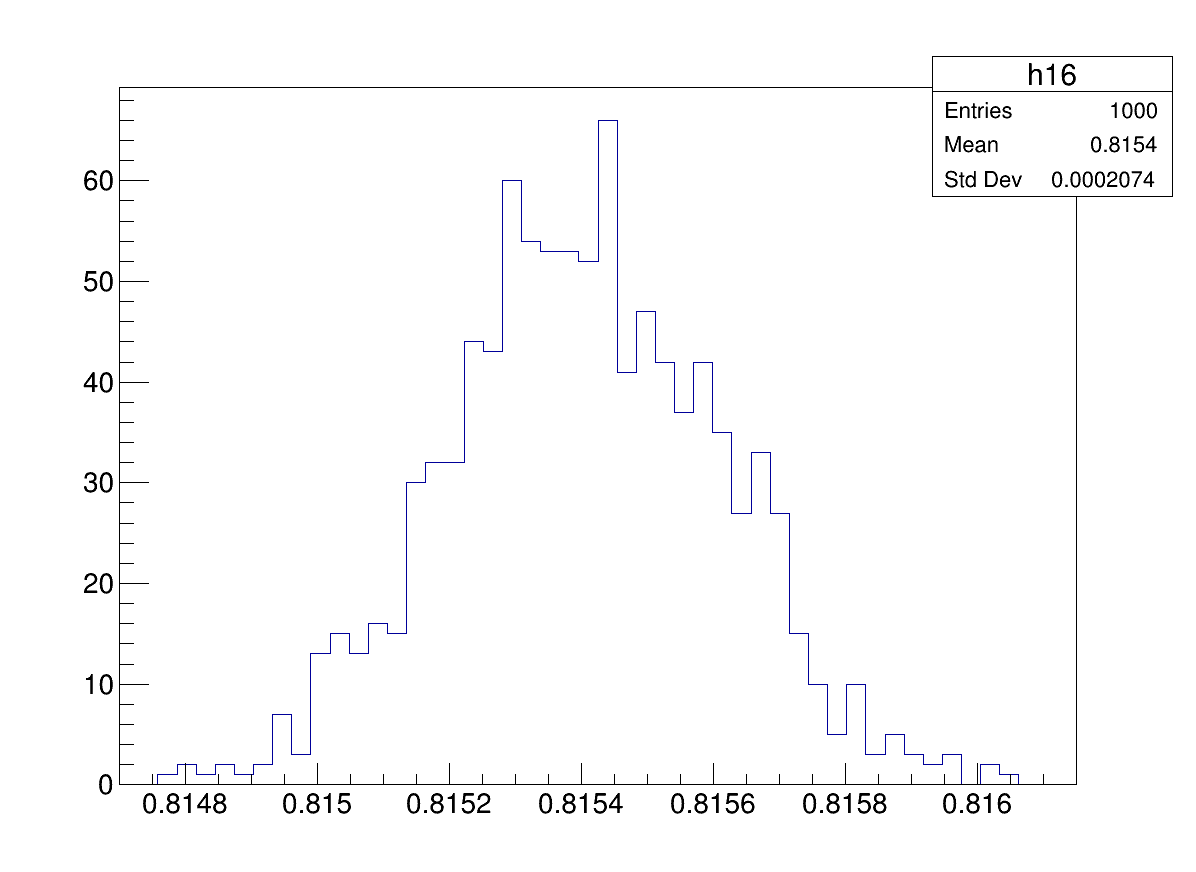

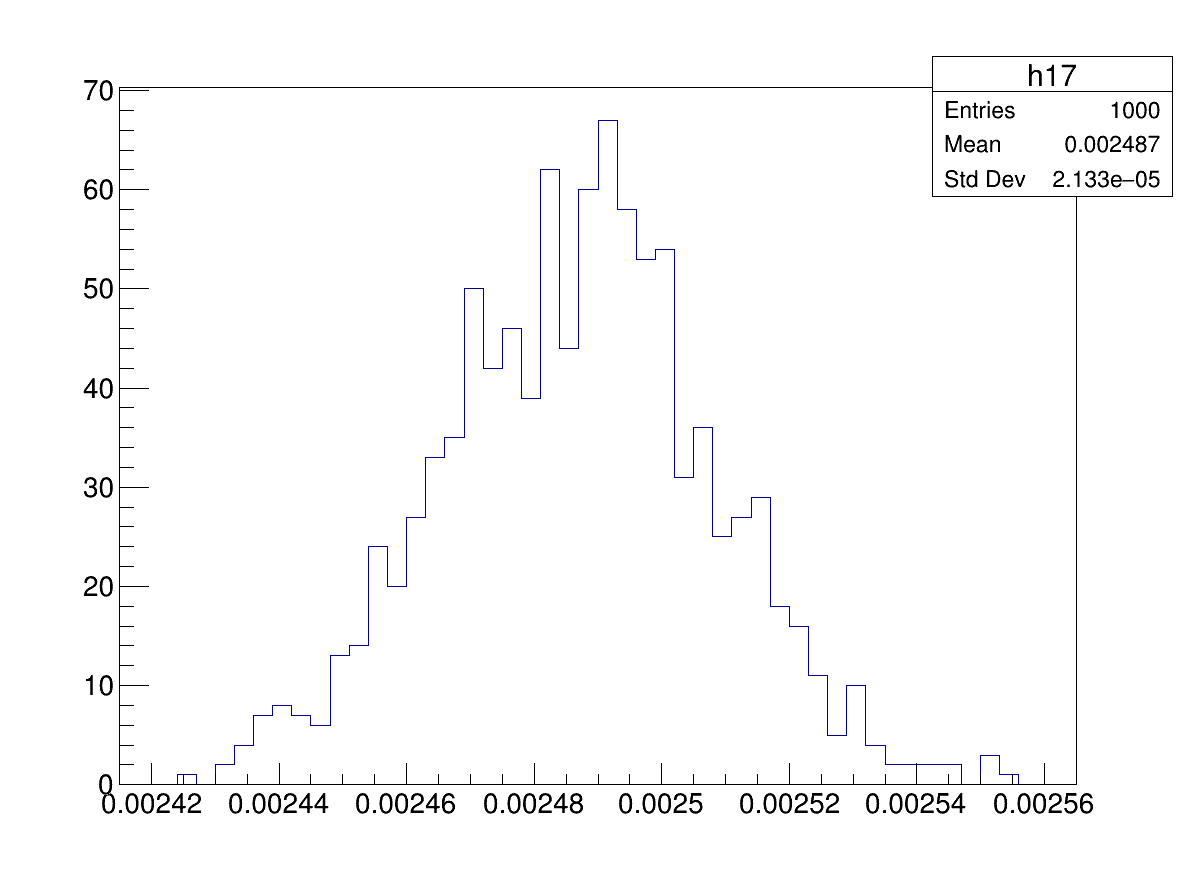

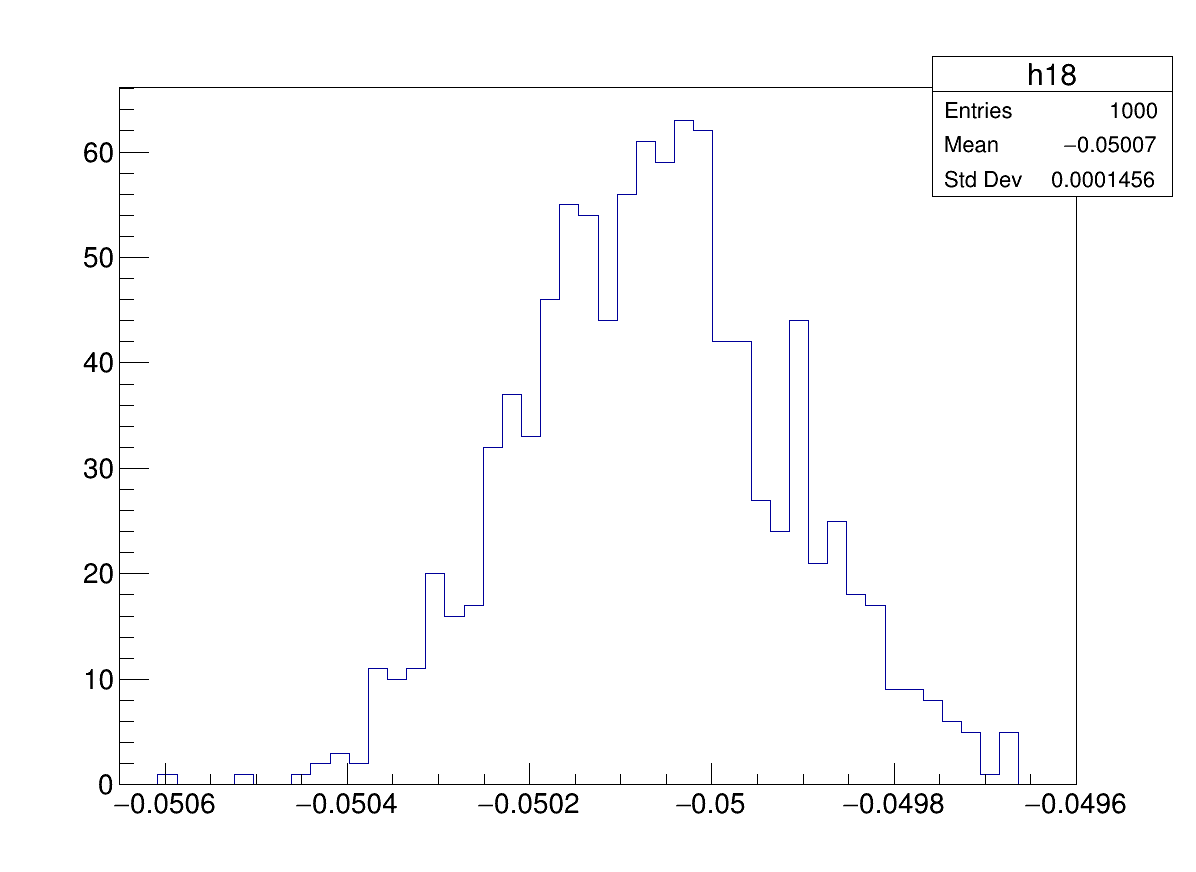

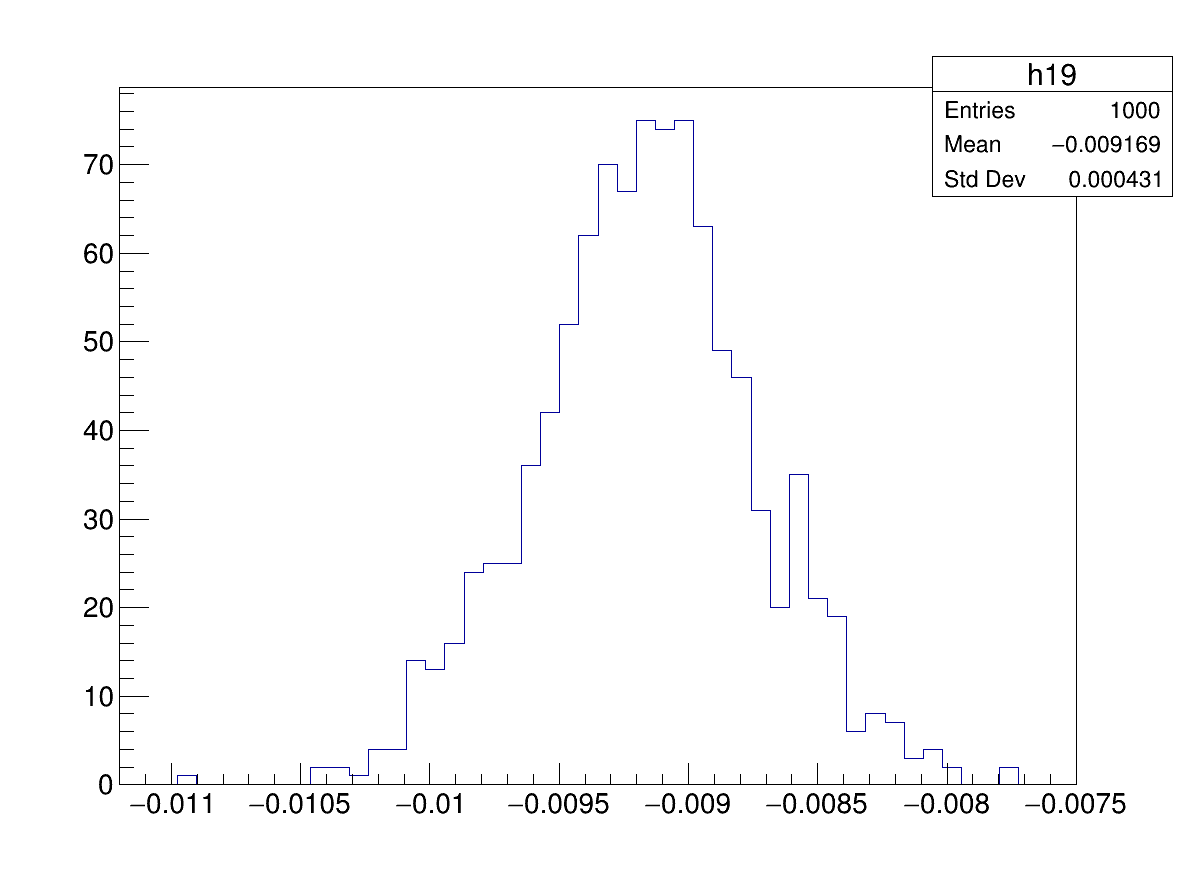

In [14]:
PlotSmearedDistributions("ExternalStrongPhases");